# Chapter 115 — Computer Graphics Basics

> **Prerequisites:** ch114 (Affine Transformations), ch092–093 (Coordinates)
>
> **Outcomes:** Map 3D world to 2D screen; Understand the graphics pipeline; Implement basic perspective projection; Rasterize a triangle


## The Graphics Pipeline

The path from 3D geometry to screen pixels:

1. **Model space** → **World space**: apply model transform (position/orient the object)
2. **World space** → **Camera space**: apply view transform (move world relative to camera)
3. **Camera space** → **Clip space**: apply projection (perspective or orthographic)
4. **Clip space** → **NDC**: normalize device coordinates [-1,1]³
5. **NDC** → **Screen space**: viewport transform (map to pixel coordinates)

Each step is a matrix multiplication. The full transform per vertex:
v_screen = M_viewport · M_project · M_view · M_model · v_world

This is 4 matrix multiplications in sequence, done on every vertex — the heart of the GPU.

## Perspective Projection

**Perspective projection** makes distant objects appear smaller:
x' = f·x/z,  y' = f·y/z

where f is the focal length. The division by z is non-linear —
it cannot be represented as a standard matrix multiplication.

However, using homogeneous coordinates:
P_proj = [[f,0,0,0],[0,f,0,0],[0,0,1,1],[0,0,0,0]] · [x,y,z,1]ᵀ = [fx,fy,z,z]

Then divide by the w component (z) to get normalized coords: (fx/z, fy/z, 1).

**Orthographic projection** (no perspective): simply drop z.
P_ortho = [[1,0,0],[0,1,0]] · [x,y,z]ᵀ = [x,y]

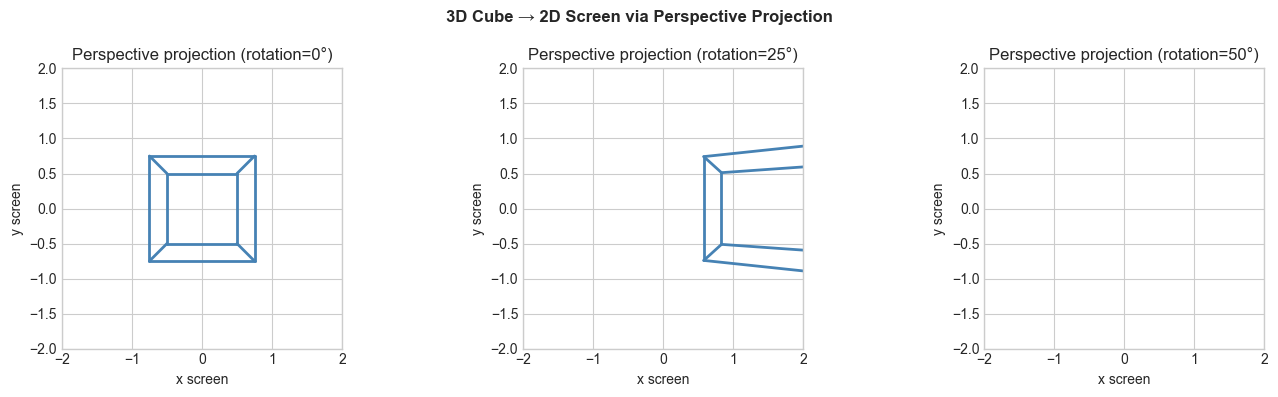

In [1]:
# --- Projection and rendering ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def perspective_project(pts3d, f=2.0):
    """Project (N,3) points to (N,2) using perspective: x' = f*x/z, y' = f*y/z."""
    pts = np.asarray(pts3d, dtype=float)
    z = pts[:,2]
    x2d = f * pts[:,0] / z
    y2d = f * pts[:,1] / z
    return np.column_stack([x2d, y2d])

def rotate_y(pts, theta):
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    return (R @ pts.T).T

# 3D cube vertices and edges
v = np.array([[-1,-1,-1],[-1,-1,1],[-1,1,-1],[-1,1,1],
               [1,-1,-1],[1,-1,1],[1,1,-1],[1,1,1]], dtype=float)
edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
v_scene = v + np.array([0,0,5])  # move cube 5 units in front

fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax, angle in zip(axes, [0, 25, 50]):
    v_rot = rotate_y(v_scene, np.radians(angle))
    projected = perspective_project(v_rot, f=3)
    for i,j in edges:
        ax.plot([projected[i,0],projected[j,0]],[projected[i,1],projected[j,1]],'steelblue',lw=2)
    ax.set_aspect('equal'); ax.set_xlim(-2,2); ax.set_ylim(-2,2)
    ax.set_title(f'Perspective projection (rotation={angle}°)')
    ax.set_xlabel('x screen'); ax.set_ylabel('y screen')

plt.suptitle('3D Cube → 2D Screen via Perspective Projection', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Rasterization



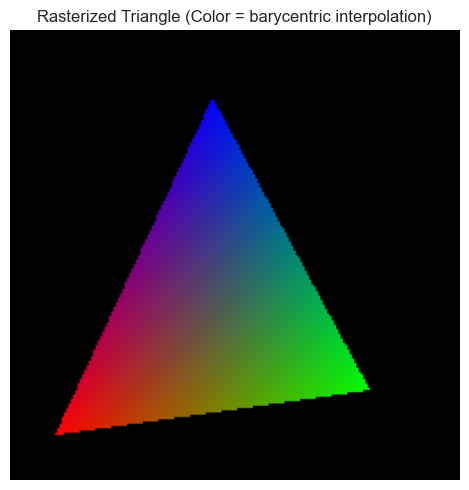

In [3]:
# --- Triangle rasterization ---
import numpy as np
import matplotlib.pyplot as plt

def rasterize_triangle(v0, v1, v2, width=200, height=200):
    """Fill a triangle using barycentric coordinates."""
    canvas = np.zeros((height, width, 3))
    xmin = max(0, int(min(v0[0],v1[0],v2[0])))
    xmax = min(width-1, int(max(v0[0],v1[0],v2[0]))+1)
    ymin = max(0, int(min(v0[1],v1[1],v2[1])))
    ymax = min(height-1, int(max(v0[1],v1[1],v2[1]))+1)
    
    def edge_fn(a,b,p):
        return (p[0]-a[0])*(b[1]-a[1]) - (p[1]-a[1])*(b[0]-a[0])
    
    area = edge_fn(v0,v1,v2)
    for y in range(ymin, ymax):
        for x in range(xmin, xmax):
            p = (x+0.5, y+0.5)
            w0 = edge_fn(v1,v2,p)/area
            w1 = edge_fn(v2,v0,p)/area
            w2 = edge_fn(v0,v1,p)/area
            if w0>=0 and w1>=0 and w2>=0:
                # Color = barycentric interpolation of vertex colors
                canvas[y,x] = w0*np.array([1,0,0]) + w1*np.array([0,1,0]) + w2*np.array([0,0,1])
    return canvas

canvas = rasterize_triangle((20,20),(160,40),(90,170))
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(canvas, origin='lower'); ax.set_title('Rasterized Triangle (Color = barycentric interpolation)')
ax.axis('off'); plt.tight_layout(); plt.show()

## Summary

- Graphics pipeline: 5 matrix transforms per vertex: model→world→camera→clip→screen
- Perspective: x'=f·x/z — cannot be linear, needs homogeneous coordinate trick
- Rasterization: for each pixel, test if inside triangle using edge functions
- Barycentric coordinates (w₀,w₁,w₂) interpolate any per-vertex attribute

**Forward:** ch164 (Linear Transformations) formalizes the matrix pipeline; ch177 (Word Embeddings) uses similar projection ideas for dimensionality reduction.